# Lizard Species Prediction – Verbeterde versie
**Thomas More – Deep Learning Project**

## 1. Imports & Configuratie

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

print(f"TensorFlow versie: {tf.__version__}")
print(f"GPU beschikbaar: {len(tf.config.list_physical_devices('GPU')) > 0}")

I0000 00:00:1778058797.345110    9655 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778058797.435384    9655 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778058799.694827    9655 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow versie: 2.21.0
GPU beschikbaar: True


In [2]:
# ── Paden – pas aan aan jouw projectstructuur ──
BASE_DIR  = Path("lizard-prediction-thomas-more")
TRAIN_DIR = BASE_DIR / "train"   # bevat submappen per klasse
TEST_DIR  = BASE_DIR / "test"    # bevat losse afbeeldingen (1.jpg, 2.jpg, ...)

TRAIN_CSV  = BASE_DIR / "train.csv"         # kolommen: id (bestandsnaam), label (0-6)
TEST_CSV   = BASE_DIR / "test.csv"          # kolom: id (integer)
SAMPLE_SUB = BASE_DIR / "sample_submission.csv"

# Hyperparameters
IMG_SIZE   = (224, 224)   # groter dan v1 (was 128x128)
BATCH_SIZE = 32
SEED       = 42
NUM_TTA    = 5            # aantal augmentaties voor Test Time Augmentation

# Class mapping (volgorde alfabetisch, overeenkomstig train.csv labels)
CLASS_NAMES = [
    "Black_spiny-tailed_iguana",  # 0
    "Brown_anole",                # 1
    "Cuban_knight_anole",         # 2
    "Desert_iguana",              # 3
    "Green_anole",                # 4
    "Green_iguana",               # 5
    "Lesser_Antillean_iguana",    # 6
]
NUM_CLASSES = len(CLASS_NAMES)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print(f"Aantal klassen: {NUM_CLASSES}")

Aantal klassen: 7


## 2. 🔍 EDA – Data verkennen

In [3]:
# Laad de CSV's
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print(train_df.head())
print("\nLabel verdeling:")
print(train_df['label'].value_counts().sort_index())
print("\nTest shape:", test_df.shape)
print(test_df.head())

Train shape: (1334, 2)
                                                  id  label
0  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0

Label verdeling:
label
0    199
1    193
2    189
3    183
4    178
5    196
6    196
Name: count, dtype: int64

Test shape: (326, 1)
   id
0   1
1   2
2   3
3   4
4   5


In [4]:
# Voeg volledige bestandspaden toe aan train_df
# De 'id' kolom in train.csv is de bestandsnaam (bijv. 'Black_spiny-tailed_iguana_1.jpg')
# Afbeeldingen zitten in submappen per klasse: train/Black_spiny-tailed_iguana/...

def find_image_path(row):
    """Zoek het volledige pad op basis van de bestandsnaam in de train map."""
    filename = row['id']
    label = row['label']
    cls_name = CLASS_NAMES[label]
    # Probeer in de klassensubmap
    candidate = TRAIN_DIR / cls_name / filename
    if candidate.exists():
        return str(candidate)
    # Fallback: zoek in alle submappen
    for subdir in TRAIN_DIR.iterdir():
        p = subdir / filename
        if p.exists():
            return str(p)
    return None

train_df['filepath'] = train_df.apply(find_image_path, axis=1)
missing = train_df['filepath'].isna().sum()
print(f"Ontbrekende afbeeldingen: {missing}/{len(train_df)}")
train_df = train_df.dropna(subset=['filepath'])
print(f"Bruikbare samples: {len(train_df)}")

Ontbrekende afbeeldingen: 0/1334
Bruikbare samples: 1334


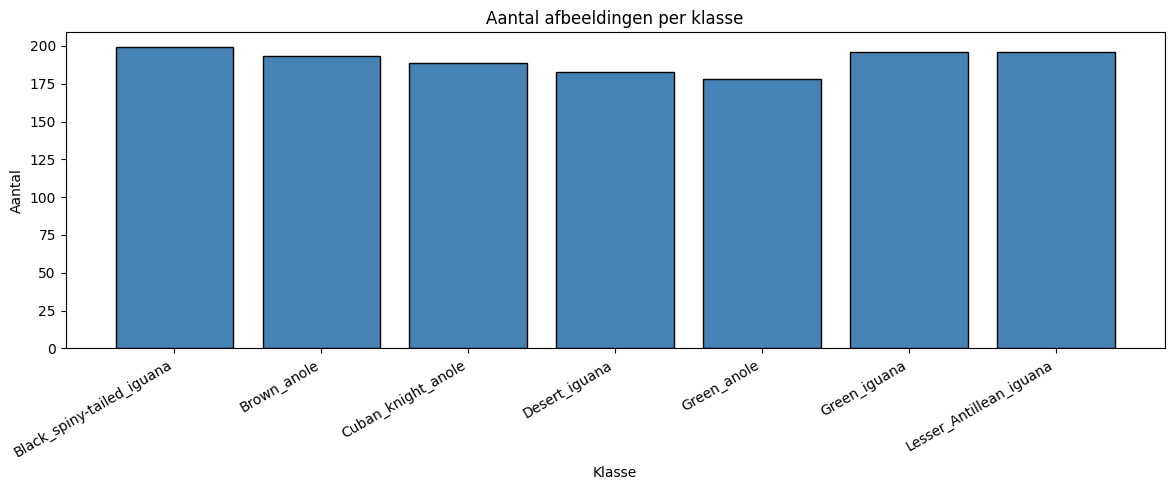

In [5]:
# Klassen-verdeling visualiseren
label_counts = train_df['label'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.bar([CLASS_NAMES[i] for i in label_counts.index], label_counts.values,
        color='steelblue', edgecolor='black')
plt.title("Aantal afbeeldingen per klasse")
plt.xlabel("Klasse")
plt.ylabel("Aantal")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. 🔄 Dataset maken met tf.data (efficiënt & correct)

In [6]:
# Train / validatie split op dataframe-niveau (stratified)
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=SEED
)
print(f"Train samples: {len(train_split)}")
print(f"Val samples:   {len(val_split)}")

Train samples: 1067
Val samples:   267


In [7]:
# EfficientNetV2 preprocessing (rescale naar [-1, 1])
PREPROCESS_FN = keras.applications.efficientnet_v2.preprocess_input

def load_and_preprocess(filepath, label, augment=False):
    """Laad een afbeelding, pas augmentatie toe en geef terug als tensor."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.image.random_hue(img, 0.1)
        # Willekeurige rotatie via keras layer (hieronder als aparte layer)
    img = PREPROCESS_FN(img)
    label_onehot = tf.one_hot(label, NUM_CLASSES)
    return img, label_onehot

def make_dataset(df, augment=False, shuffle=False):
    paths  = df['filepath'].tolist()
    labels = df['label'].tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_split, augment=True, shuffle=True)
val_ds   = make_dataset(val_split,   augment=False, shuffle=False)

print("Datasets klaar!")

I0000 00:00:1778058807.798592    9655 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets klaar!


## 4. Model bouwen – EfficientNetV2S + Fine-tuning

In [8]:
# Data augmentatie als model-lagen (worden enkel tijdens training toegepast)
augmentation_layers = keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

# EfficientNetV2S – beter dan MobileNetV2 voor nauwkeurigheid
base_model = keras.applications.EfficientNetV2S(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Fase 1: alleen het hoofd trainen

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = augmentation_layers(inputs)  # augmentatie enkel tijdens training
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,992,871 (80.08 MB)

 Trainable params: 660,487 (2.52 MB)

 Non-trainable params: 20,332,384 (77.56 MB)

In [9]:
# Fase 1: alleen classificatie-hoofd trainen (backbone bevroren)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    # Label smoothing vermindert overfitten
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_fase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_fase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("=== Fase 1: Hoofd trainen ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_fase1
)

=== Fase 1: Hoofd trainen ===
Epoch 1/15


I0000 00:00:1778058824.490879    9978 cuda_dnn.cc:461] Loaded cuDNN version 92101


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.2904 - loss: 2.5564
Epoch 1: val_accuracy improved from None to 0.55056, saving model to best_model_fase1.keras

Epoch 1: finished saving model to best_model_fase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 409ms/step - accuracy: 0.3533 - loss: 2.3746 - val_accuracy: 0.5506 - val_loss: 1.4015 - learning_rate: 0.0010
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5221 - loss: 1.7084
Epoch 2: val_accuracy did not improve from 0.55056
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - accuracy: 0.5201 - loss: 1.7036 - val_accuracy: 0.4719 - val_loss: 1.4348 - learning_rate: 0.0010
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5799 - loss: 1.4881
Epoch 3: val_accuracy improved from 0.55056 to 0.59925, saving model to best_model_fase1.keras

Epoch 3: finished saving model to best_model_fase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.5633 - loss: 1.5152 - val_accuracy: 0.5993 - val_loss: 1.2974

In [10]:
# Fase 2: Fine-tuning – ontgrendel de laatste lagen van backbone
base_model.trainable = True

# Bevries alles behalve de laatste 30 lagen
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainbare lagen na ontgrendelen: {sum(1 for l in model.layers if l.trainable)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Zeer lage LR!
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_fase2 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_model_fase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("=== Fase 2: Fine-tuning ===")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_fase2
)

Trainbare lagen na ontgrendelen: 8
=== Fase 2: Fine-tuning ===
Epoch 1/25


E0000 00:00:1778058973.311241    9655 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7146 - loss: 1.0841
Epoch 1: val_accuracy improved from None to 0.65169, saving model to best_model_fase2.keras

Epoch 1: finished saving model to best_model_fase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 375ms/step - accuracy: 0.7160 - loss: 1.0876 - val_accuracy: 0.6517 - val_loss: 1.2619 - learning_rate: 1.0000e-05
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7286 - loss: 1.0710
Epoch 2: val_accuracy improved from 0.65169 to 0.67041, saving model to best_model_fase2.keras

Epoch 2: finished saving model to best_model_fase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - accuracy: 0.7329 - loss: 1.0805 - val_accuracy: 0.6704 - val_loss: 1.2444 - learning_rate: 1.0000e-05
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7340 - loss: 1.0211
Epoch 3: val_accuracy did not improve from 0.67041
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 227ms/step - accuracy: 0.7338 - loss: 1.0459 - val_accuracy: 0.6629 - val_los

## 5. 📈 Training visualiseren

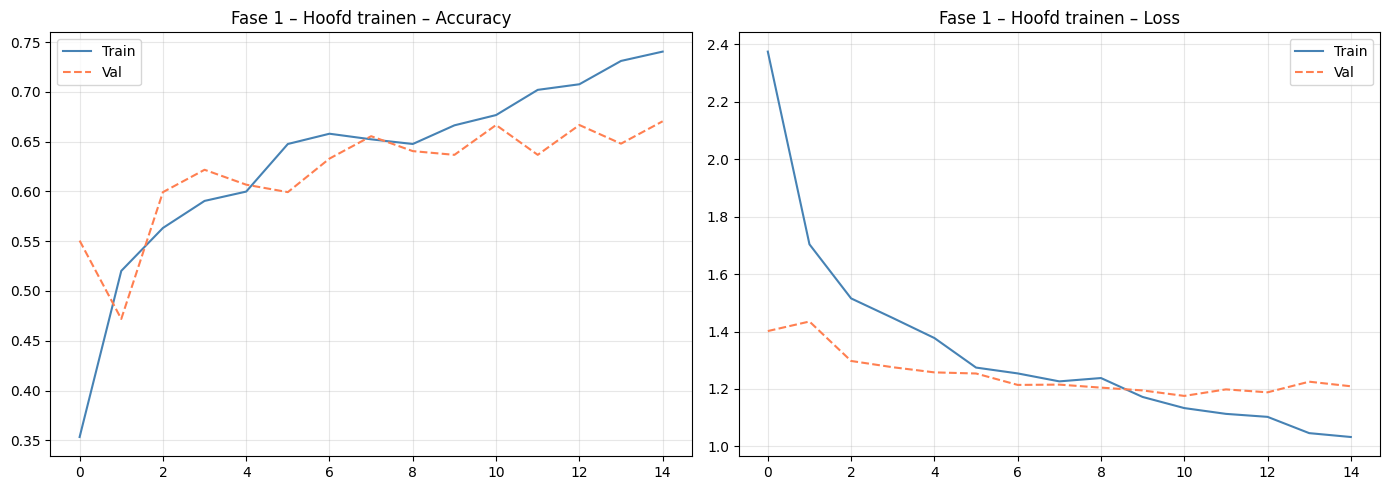

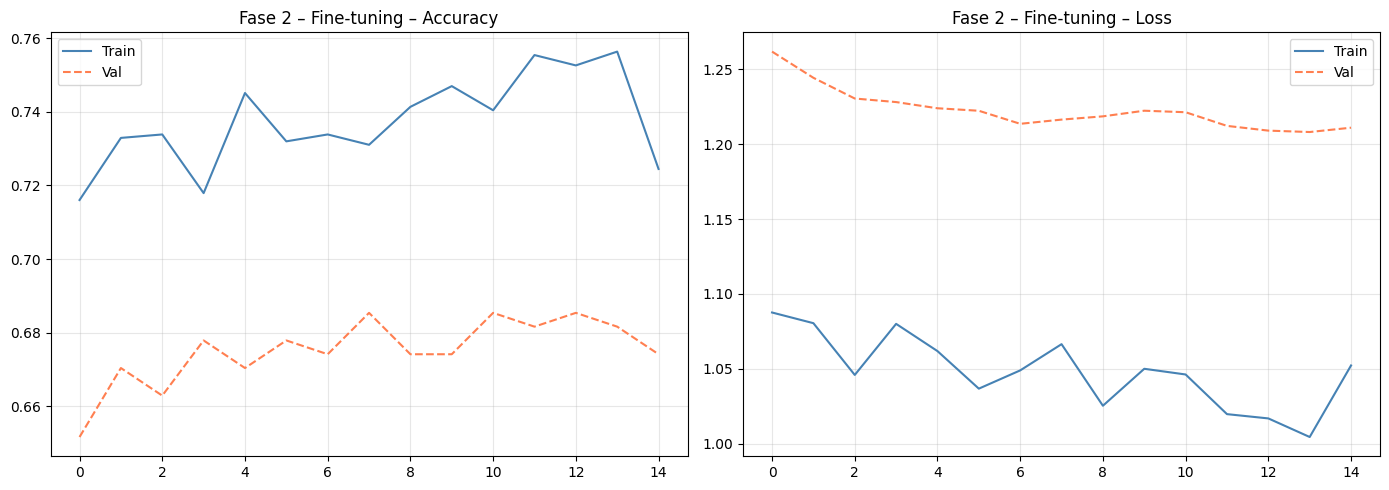

In [11]:
def plot_history(h, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(h.history['accuracy'],     label='Train', color='steelblue')
    ax1.plot(h.history['val_accuracy'], label='Val',   color='coral', linestyle='--')
    ax1.set_title(f'{title} – Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(h.history['loss'],     label='Train', color='steelblue')
    ax2.plot(h.history['val_loss'], label='Val',   color='coral', linestyle='--')
    ax2.set_title(f'{title} – Loss'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history1, "Fase 1 – Hoofd trainen")
plot_history(history2, "Fase 2 – Fine-tuning")

## 6. 📊 Evaluatie op validatieset

In [12]:
# Beste model laden
best_model = keras.models.load_model('best_model_fase2.keras')

val_loss, val_acc = best_model.evaluate(val_ds, verbose=0)
print(f"Validatie accuracy: {val_acc:.4f}")
print(f"Validatie loss:     {val_loss:.4f}")

Validatie accuracy: 0.6854
Validatie loss:     1.2165


9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 744ms/step

Classification Report:
                           precision    recall  f1-score   support

Black_spiny-tailed_iguana       0.74      0.93      0.82        40
              Brown_anole       0.58      0.67      0.62        39
       Cuban_knight_anole       0.59      0.58      0.59        38
            Desert_iguana       1.00      0.92      0.96        37
              Green_anole       0.48      0.43      0.45        35
             Green_iguana       0.74      0.59      0.66        39
  Lesser_Antillean_iguana       0.67      0.67      0.67        39

                 accuracy                           0.69       267
                macro avg       0.69      0.68      0.68       267
             weighted avg       0.69      0.69      0.68       267



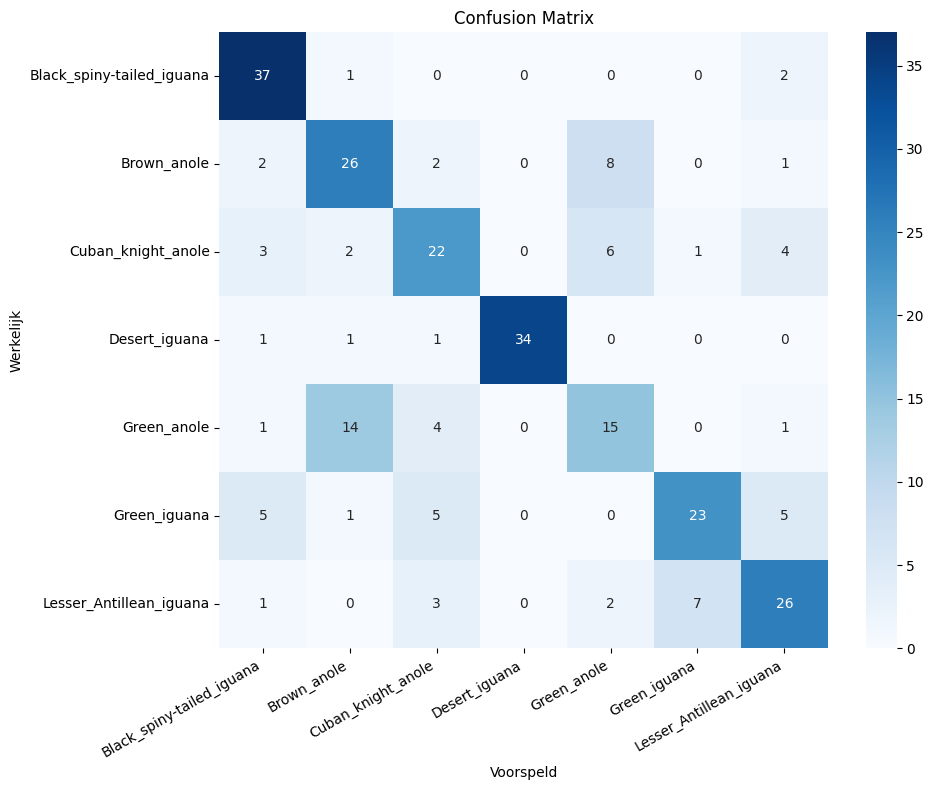

In [13]:
# Voorspellingen op validatieset
y_pred_proba = best_model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# Echte labels ophalen
y_true = val_split['label'].tolist()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix"); plt.xlabel("Voorspeld"); plt.ylabel("Werkelijk")
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 7. 🏆 Kaggle Submission – met Test Time Augmentation (TTA)

In [14]:
# Test images inladen
# De test map bevat afbeeldingen als: 1.jpg, 2.jpg, ..., 326.jpg
test_df = pd.read_csv(TEST_CSV)

def get_test_path(img_id):
    """Zoek het testbestand op basis van integer ID."""
    for ext in ['.jpg', '.jpeg', '.png']:
        p = TEST_DIR / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

test_df['filepath'] = test_df['id'].apply(get_test_path)
missing_test = test_df['filepath'].isna().sum()
print(f"Test samples gevonden: {test_df['filepath'].notna().sum()}/{len(test_df)}")
if missing_test > 0:
    print(f"⚠️ Ontbrekende test-afbeeldingen: {missing_test}")

Test samples gevonden: 326/326


In [15]:
def load_test_image(filepath, augment=False):
    """Laad testafbeelding voor inferentie."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
    img = PREPROCESS_FN(img)
    return img

def make_test_dataset(filepaths, augment=False):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(lambda p: load_test_image(p, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_filepaths = test_df['filepath'].tolist()

# TTA: meerdere inferenties met willekeurige augmentatie middelen
print(f"TTA met {NUM_TTA} runs...")
all_probs = []

# Eerste run: zonder augmentatie
test_ds_plain = make_test_dataset(test_filepaths, augment=False)
all_probs.append(best_model.predict(test_ds_plain, verbose=0))

# Overige runs: met augmentatie
for i in range(NUM_TTA - 1):
    test_ds_aug = make_test_dataset(test_filepaths, augment=True)
    all_probs.append(best_model.predict(test_ds_aug, verbose=0))
    print(f"  TTA run {i+2}/{NUM_TTA} klaar")

# Gemiddelde van alle runs
avg_probs = np.mean(all_probs, axis=0)
predicted_labels = np.argmax(avg_probs, axis=1)

print("\nVerdeling van voorspellingen:")
for lbl, cnt in Counter(predicted_labels).most_common():
    print(f"  {lbl} ({CLASS_NAMES[lbl]}): {cnt}")

TTA met 5 runs...
  TTA run 2/5 klaar
  TTA run 3/5 klaar
  TTA run 4/5 klaar
  TTA run 5/5 klaar

Verdeling van voorspellingen:
  3 (Desert_iguana): 55
  6 (Lesser_Antillean_iguana): 54
  2 (Cuban_knight_anole): 50
  0 (Black_spiny-tailed_iguana): 46
  1 (Brown_anole): 44
  5 (Green_iguana): 40
  4 (Green_anole): 37


In [16]:
# Submission maken
submission = pd.DataFrame({
    'id':    test_df['id'].tolist(),
    'label': predicted_labels.tolist()
})

# Sanity check: zelfde structuur als sample_submission
sample_sub = pd.read_csv(SAMPLE_SUB)
assert list(submission.columns) == list(sample_sub.columns), "Kolommen komen niet overeen!"
assert len(submission) == len(sample_sub), f"Aantal rijen klopt niet: {len(submission)} vs {len(sample_sub)}"
assert submission['label'].between(0, NUM_CLASSES - 1).all(), "Ongeldige labels!"

print("✅ Submission sanity checks geslaagd!")
print(submission.head(10))

submission.to_csv('submission.csv', index=False)
print("\n✅ submission.csv opgeslagen!")

✅ Submission sanity checks geslaagd!
   id  label
0   1      6
1   2      5
2   3      6
3   4      5
4   5      0
5   6      2
6   7      6
7   8      2
8   9      4
9  10      1

✅ submission.csv opgeslagen!


## ✅ Samenvatting van verbeteringen

| Onderdeel | v1 (score ~0.09) | v2 (verbeterd) |
|-----------|------------------|----------------|
| **Data laden** | `flow_from_directory` (negeerde train.csv) | `tf.data` via `train.csv` (correct!) |
| **Image grootte** | 128×128 | 224×224 |
| **Backbone** | MobileNetV2 | EfficientNetV2S |
| **Label smoothing** | ❌ | ✅ (0.1) |
| **TTA** | ❌ | ✅ (5 runs) |
| **Augmentatie** | Basis | Brightness, contrast, hue, saturation |
| **Test-IDs koppeling** | Fout (generator volgorde) | Correct (via filepath → id mapping) |

### 💡 Extra tips als de score nog niet hoog genoeg is:
- Probeer `EfficientNetV2M` of `EfficientNetV2L` als je GPU krachtig genoeg is
- Verhoog `NUM_TTA` naar 10
- Voeg `Mixup` of `CutMix` augmentatie toe
- Train meerdere modellen en ensemble ze